
# N=8 Kuramoto benchmark — dynamics-first structural inference with joint refinement

This notebook keeps the **same N=8 Kuramoto generator** as the earlier benchmark and tests the completed fixed-dynamics branch of the new three-layer TIDES architecture:

\[
x(t)
\longrightarrow
\tau_{1:K-1}
\longrightarrow
\mathcal B_\varepsilon
\longrightarrow
(W_{1:K},\Theta)^\star_{H_{\rm FD}}.
\]

The key Step-3 point is that the algorithm is **not** a strict two-step estimator.

First, the full structural dictionary is used to locate a shared-law basin,

\[
\Theta_0
=
\arg\min_\Theta\min_W \rho(W,\Theta).
\]

Then, for the current law \(\Theta_n\), structure is temporarily treated as a linear network-reconstruction problem,

\[
\hat a_S(\Theta_n)
=
\arg\min_a \|y-C_S(\Theta_n)a\|_2.
\]

This cheap linear problem is used only to **screen** structural supports. Every shortlisted support is subsequently re-profiled jointly,

\[
E_S
=
\min_\Theta\min_{a_S}\rho(a_S,\Theta),
\]

then quantized and scored with the full MDL objective. Thus \(\Theta\) remains free to move as \(W\) and \(\Delta W\) are reconstructed.

The inference is given neither the planted topology nor a sine atom. Synthetic truth is consulted only after inference for validation.


In [1]:

# ============================================================
# Cell 1 — imports and local-code discovery
# ============================================================
from pathlib import Path
import sys
import time
import math
import importlib

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
CODE_DIR = None
for candidate in (HERE, HERE / "tides_new", HERE.parent, Path("/mnt/data/tides_new")):
    if (candidate / "tides.py").exists():
        CODE_DIR = candidate.resolve()
        break

if CODE_DIR is None:
    raise FileNotFoundError(
        "Could not find tides.py. Put this notebook in the same directory as "
        "the new TIDES source files, or run it from their parent directory."
    )

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import tides
import step3_physical_compression as step3pc

importlib.reload(tides)
importlib.reload(step3pc)

print("TIDES loaded from:")
print(tides.__file__)
print("\nStep 3 loaded from:")
print(step3pc.__file__)


TIDES loaded from:
C:\Users\liu.xuanc\Desktop\Code\TIDES-Inference\tides.py

Step 3 loaded from:
C:\Users\liu.xuanc\Desktop\Code\TIDES-Inference\step3_physical_compression.py


In [2]:

# ============================================================
# Cell 2 — Kuramoto N=8 benchmark truth
# Same generator as the previous N=8 polynomial benchmark.
# ============================================================
from itertools import combinations

SEED = 20260811
N = 8
DT = 5.0e-4
STAGE_DURATION = 0.060
N_STAGES = 6
INTERVALS_PER_STAGE = int(round(STAGE_DURATION / DT))
assert INTERVALS_PER_STAGE == 120

CANDIDATE_EDGES = tuple(combinations(range(1, N + 1), 2))
EDGE_INDEX_1B = {edge: m for m, edge in enumerate(CANDIDATE_EDGES)}
assert len(CANDIDATE_EDGES) == 28

weight_rng = np.random.default_rng(SEED)
EDGE_WEIGHT = {
    edge: int(weight_rng.integers(800, 1201)) / 1000.0
    for edge in CANDIDATE_EDGES
}

SNAPSHOTS = (
    ((1, 3), (2, 5), (2, 8), (3, 5), (3, 8),
     (4, 6), (4, 7), (5, 6), (6, 8), (7, 8)),
    ((1, 3), (1, 5), (2, 3), (2, 8), (3, 5),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 3), (2, 7), (2, 8),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 4), (1, 6), (2, 7), (2, 8),
     (3, 8), (4, 5), (4, 6), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 7), (2, 8), (3, 8),
     (4, 5), (5, 6), (5, 7), (6, 7), (7, 8)),
    ((1, 3), (1, 8), (2, 8), (3, 8), (4, 5),
     (4, 8), (5, 6), (5, 7), (6, 7), (7, 8)),
)

X0 = np.array([
    -0.319989, -0.301418, 0.354093, -0.213312,
    -0.026615,  0.067347, 0.282008,  0.157887,
], dtype=float)
X0 -= X0.mean()


def edge_field(x, edge):
    i, j = edge
    i -= 1
    j -= 1
    q = EDGE_WEIGHT[edge] * np.sin(x[j] - x[i])
    out = np.zeros_like(x, dtype=float)
    out[i] += q
    out[j] -= q
    return out


def stage_field(x, stage):
    out = np.zeros(N, dtype=float)
    for edge in SNAPSHOTS[stage]:
        out += edge_field(x, edge)
    return out


def rk4_step(x, dt, stage):
    k1 = stage_field(x, stage)
    k2 = stage_field(x + 0.5 * dt * k1, stage)
    k3 = stage_field(x + 0.5 * dt * k2, stage)
    k4 = stage_field(x + dt * k3, stage)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def is_connected(edge_set):
    adjacency = {i: set() for i in range(1, N + 1)}
    for i, j in edge_set:
        adjacency[i].add(j)
        adjacency[j].add(i)
    seen, stack = {1}, [1]
    while stack:
        u = stack.pop()
        for v in adjacency[u]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return len(seen) == N


transition_supports_true = []
for k in range(N_STAGES - 1):
    before = set(SNAPSHOTS[k])
    after = set(SNAPSHOTS[k + 1])
    transition_supports_true.append(tuple(sorted(before ^ after)))

assert all(len(snapshot) == 10 for snapshot in SNAPSHOTS)
assert all(is_connected(snapshot) for snapshot in SNAPSHOTS)
assert all(len(S) == 4 for S in transition_supports_true)

true_change_times = np.arange(1, N_STAGES) * STAGE_DURATION
true_transition_indices = np.rint(true_change_times / DT).astype(int)

print("=" * 90)
print("N=8 Kuramoto benchmark truth")
print("=" * 90)
print("candidate edges M       :", len(CANDIDATE_EDGES))
print("active edges / stage    :", [len(G) for G in SNAPSHOTS])
print("true edge law           : sin(x_neighbor - x_self)")
print("true change times       :", true_change_times)
print("true transition indices :", true_transition_indices)
for k, S in enumerate(transition_supports_true, 1):
    print(f"transition {k}: {S}")


N=8 Kuramoto benchmark truth
candidate edges M       : 28
active edges / stage    : [10, 10, 10, 10, 10, 10]
true edge law           : sin(x_neighbor - x_self)
true change times       : [0.06 0.12 0.18 0.24 0.3 ]
true transition indices : [120 240 360 480 600]
transition 1: ((1, 5), (2, 3), (2, 5), (6, 8))
transition 2: ((1, 5), (1, 6), (2, 7), (3, 5))
transition 3: ((1, 4), (2, 3), (4, 5), (4, 7))
transition 4: ((1, 4), (4, 6), (5, 7), (6, 7))
transition 5: ((1, 6), (1, 8), (2, 7), (4, 8))


Kuramoto trajectory generated
X shape                : (721, 8)
||X(T)-X(0)||          : 4.527580e-01
max |x_i(t)|           : 3.540929e-01
sum_i x_i change       : -3.608225e-16
all finite             : True


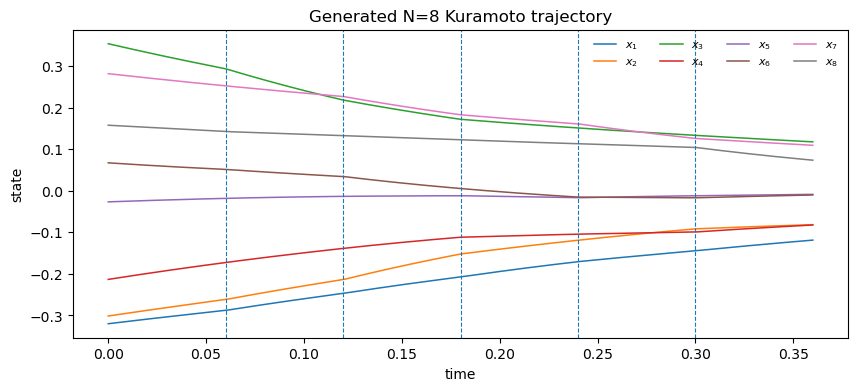

In [3]:

# ============================================================
# Cell 3 — Generate the trajectory
# ============================================================
n_total_intervals = N_STAGES * INTERVALS_PER_STAGE
T = np.arange(n_total_intervals + 1, dtype=float) * DT
X = np.empty((n_total_intervals + 1, N), dtype=float)
X[0] = X0

true_stage_of_interval = np.repeat(
    np.arange(N_STAGES, dtype=int), INTERVALS_PER_STAGE
)
for n, stage in enumerate(true_stage_of_interval):
    X[n + 1] = rk4_step(X[n], DT, int(stage))

t = T.copy()

state_displacement = np.linalg.norm(X[-1] - X[0])
max_abs_state = np.max(np.abs(X))
net_sum_change = float(X[-1].sum() - X[0].sum())

print("=" * 90)
print("Kuramoto trajectory generated")
print("=" * 90)
print("X shape                :", X.shape)
print("||X(T)-X(0)||          :", f"{state_displacement:.6e}")
print("max |x_i(t)|           :", f"{max_abs_state:.6e}")
print("sum_i x_i change       :", f"{net_sum_change:.6e}")
print("all finite             :", np.isfinite(X).all())

assert X.shape == (721, 8)
assert np.allclose(np.diff(t), DT)
assert np.isfinite(X).all()
assert abs(net_sum_change) < 1e-10

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax.plot(t, X[:, i], lw=1.1, label=f"$x_{i+1}$")
for tc in true_change_times:
    ax.axvline(tc, ls="--", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("state")
ax.set_title("Generated N=8 Kuramoto trajectory")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()


STEP 1 — blind temporal segmentation
jump median       : 2.052779750772e-03
jump MAD          : 3.333185449132e-04
blind threshold   : 8.719150649037e-03
true indices      : [120 240 360 480 600]
detected indices  : [120 240 360 480 600]
detected times    : [0.06 0.12 0.18 0.24 0.3 ]


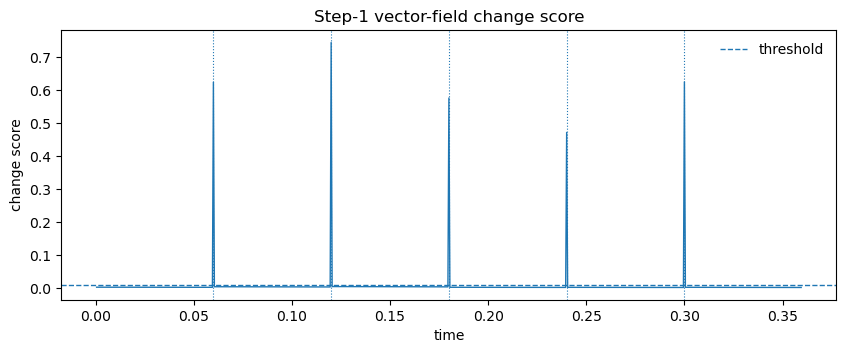

TIDES STEP 1: PASS


In [4]:

# ============================================================
# Cell 4 — Candidate-edge incidence matrix and blind Step-1 threshold
# ============================================================
M = len(CANDIDATE_EDGES)
D = np.zeros((N, M), dtype=float)
for m, (i, j) in enumerate(CANDIDATE_EDGES):
    D[i - 1, m] = -1.0
    D[j - 1, m] = +1.0

# Same fully blind robust threshold used in the earlier notebook.
V_SECANT = np.diff(X, axis=0) / DT
jump = np.linalg.norm(V_SECANT[1:] - V_SECANT[:-1], axis=1)
jump_median = float(np.median(jump))
jump_mad = float(np.median(np.abs(jump - jump_median)))
blind_threshold = jump_median + 20.0 * jump_mad

s1_check = tides.detect_changes(
    X,
    t,
    method="secant",
    threshold=blind_threshold,
    min_separation=1,
)

print("=" * 90)
print("STEP 1 — blind temporal segmentation")
print("=" * 90)
print("jump median       :", f"{jump_median:.12e}")
print("jump MAD          :", f"{jump_mad:.12e}")
print("blind threshold   :", f"{blind_threshold:.12e}")
print("true indices      :", true_transition_indices)
print("detected indices  :", s1_check.transition_indices)
print("detected times    :", s1_check.transition_times)

assert np.array_equal(s1_check.transition_indices, true_transition_indices)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(s1_check.score_times, s1_check.scores, lw=1.0)
ax.axhline(blind_threshold, ls="--", lw=1.0, label="threshold")
for tc in true_change_times:
    ax.axvline(tc, ls=":", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("change score")
ax.set_title("Step-1 vector-field change score")
ax.legend(frameon=False)
plt.show()

print("TIDES STEP 1: PASS")



## Steps 1–2 only

We first build the temporal segmentation, midpoint/derivative observations, interaction library, and the Step-2 observational family

\[
\mathcal B_\varepsilon.
\]

Physical compression is deliberately disabled in this call so that Step 3 is tested exactly once below.


In [8]:

# ============================================================
# Cell 5 — Run Steps 1–2 from the raw trajectory
# ============================================================
POLY_DEGREE = 11

t0 = time.perf_counter()

BASE = tides.run_tides(
    X,
    t,
    D,
    step1_kwargs={
        "method": "secant",
        "threshold": blind_threshold,
        "min_separation": 1,
    },
    preprocessing_method="four_point_midpoint",
    resolution_audit=True,
    uncertainty_multiplier=20.0,
    
    # library_mode="relative_polynomial",
    # library_degree=POLY_DEGREE,

    library_mode="candidate",
    # interaction_atoms=common_candidate_atoms("difference", harmonics=(1,)),
    
    check_sampled_swap_equivariance=True,
    step2_kwargs={
        "design_mode": "dense",
        "solver_method": "dense_lstsq",
    },
    run_physical_compression=False,
)

base_elapsed = time.perf_counter() - t0

print("=" * 90)
print("STEPS 1-2")
print("=" * 90)
print("elapsed / s                  :", f"{base_elapsed:.3f}")
print("transition indices           :", BASE.transition_indices)
print("preprocessing observations   :", BASE.preprocessing.n_observations)
print("samples / stage              :", BASE.preprocessing.samples_per_stage.tolist())
print("uncertainty floor            :", f"{BASE.uncertainty_floor:.12e}")
print("Step-2 minimum residual      :", f"{BASE.step2.minimum_relative_residual:.12e}")
print("Step-2 family empty?         :", BASE.step2.is_empty)

assert np.array_equal(BASE.transition_indices, true_transition_indices)
assert BASE.preprocessing.n_observations == 708
assert np.array_equal(BASE.preprocessing.samples_per_stage, np.array([118] * 6))
assert not BASE.step2.is_empty

print("\nSTEPS 1-2: PASS")


STEPS 1-2
elapsed / s                  : 1.202
transition indices           : [120 240 360 480 600]
preprocessing observations   : 708
samples / stage              : [118, 118, 118, 118, 118, 118]
uncertainty floor            : 1.038246121080e-11
Step-2 minimum residual      : 7.568072549788e-14
Step-2 family empty?         : False

STEPS 1-2: PASS


In [9]:

# ============================================================
# Cell 6 — Preprocessing and library audit
# ============================================================
prep = BASE.preprocessing
LOCAL_LIBRARY = BASE.interaction_library
FAMILY = BASE.field_family

DIFF_SCALE = float(LOCAL_LIBRARY.metadata["atom_metadata"][0]["difference_scale"])
L = LOCAL_LIBRARY.n_features

THETA_TAYLOR_GAUGE = np.zeros(L, dtype=float)
for p in range(1, L + 1):
    if p % 2 == 1:
        k = (p - 1) // 2
        THETA_TAYLOR_GAUGE[p - 1] = (
            ((-1.0) ** k) * DIFF_SCALE ** (p - 1) / math.factorial(p)
        )

tail = np.array([i - 1 for i, _ in CANDIDATE_EDGES], dtype=int)
head = np.array([j - 1 for _, j in CANDIDATE_EDGES], dtype=int)
d_all = (prep.x_mid[:, head] - prep.x_mid[:, tail]).ravel()
z_all = d_all / DIFF_SCALE

f_taylor_phys = DIFF_SCALE * sum(
    THETA_TAYLOR_GAUGE[p - 1] * z_all**p
    for p in range(1, L + 1)
)
f_true = np.sin(d_all)
taylor_rel_error = np.linalg.norm(f_taylor_phys - f_true) / np.linalg.norm(f_true)

print("=" * 90)
print("PREPROCESSING + INTERACTION LIBRARY")
print("=" * 90)
print("midpoint state shape          :", prep.x_mid.shape)
print("midpoint derivative shape     :", prep.velocity_mid.shape)
print("resolution relative max       :", f"{prep.resolution_relative_max:.12e}")
print("estimated uncertainty floor   :", f"{prep.estimated_uncertainty_floor:.12e}")
print("library mode                  :", LOCAL_LIBRARY.mode)
print("library feature shape         :", LOCAL_LIBRARY.endpoint_features.shape)
print("feature labels                :", LOCAL_LIBRARY.feature_labels)
print("difference scale s            :", f"{DIFF_SCALE:.12e}")
print("Taylor gauge theta            :", np.array2string(THETA_TAYLOR_GAUGE, precision=12))
print("degree-11 Taylor law rel.err  :", f"{taylor_rel_error:.12e}")

assert prep.x_mid.shape == (708, 8)
assert LOCAL_LIBRARY.endpoint_features.shape == (708, 28, 11, 2)
assert np.isclose(THETA_TAYLOR_GAUGE[0], 1.0)


KeyError: 'difference_scale'

STEP 2 — EDGE-SPACE FIELD FAMILY
reference B shape         : (6, 28, 11)
parameter count           : 1848
rank                      : 498
nullity                   : 1350
minimum relative residual : 8.324112315462e-14
uncertainty floor         : 1.038246121080e-11
slack^2                   : 1.488144471624e-19
stage ranks               : [80, 83, 87, 84, 81, 83]
stage nullities           : [228, 225, 221, 224, 227, 225]

Alternative family member
||B_alt - B_ref||        : 2.946787779702e+11
rho(B_alt)               : 8.825591065243e-12
feasible                  : True


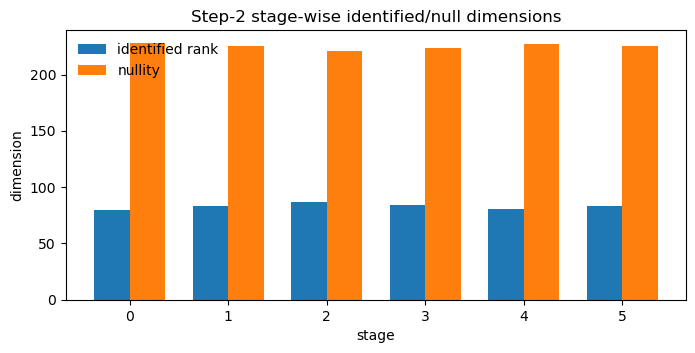

In [7]:

# ============================================================
# Cell 7 — Step 2: observational edge-space family B_epsilon
# ============================================================
print("=" * 90)
print("STEP 2 — EDGE-SPACE FIELD FAMILY")
print("=" * 90)
print("reference B shape         :", FAMILY.reference_B_stages.shape)
print("parameter count           :", FAMILY.parameter_count)
print("rank                      :", FAMILY.rank)
print("nullity                   :", FAMILY.nullity)
print("minimum relative residual :", f"{FAMILY.minimum_relative_residual:.12e}")
print("uncertainty floor         :", f"{FAMILY.uncertainty_floor:.12e}")
print("slack^2                   :", f"{FAMILY.slack_squared:.12e}")

stage_ranks = [g.rank for g in FAMILY.stage_geometry]
stage_nullities = [g.nullity for g in FAMILY.stage_geometry]
print("stage ranks               :", stage_ranks)
print("stage nullities           :", stage_nullities)

assert FAMILY.reference_B_stages.shape == (6, 28, 11)
assert FAMILY.parameter_count == 6 * 28 * 11
assert FAMILY.rank is not None and FAMILY.nullity is not None
assert FAMILY.rank + FAMILY.nullity == FAMILY.parameter_count
assert FAMILY.minimum_relative_residual <= FAMILY.uncertainty_floor

# Explicitly exhibit another member of the same observational family.
B_ALT = FAMILY.sample_feasible(
    rng=np.random.default_rng(20260916),
    null_scale=1.0,
    boundary_fraction=0.85,
)
rho_alt = FAMILY.relative_residual(B_ALT)
distance_alt = np.linalg.norm(B_ALT - FAMILY.reference_B_stages)

print("\nAlternative family member")
print("||B_alt - B_ref||        :", f"{distance_alt:.12e}")
print("rho(B_alt)               :", f"{rho_alt:.12e}")
print("feasible                  :", FAMILY.is_feasible(B_ALT))

assert FAMILY.is_feasible(B_ALT)

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(N_STAGES)
ax.bar(x - 0.18, stage_ranks, width=0.36, label="identified rank")
ax.bar(x + 0.18, stage_nullities, width=0.36, label="nullity")
ax.set_xlabel("stage")
ax.set_ylabel("dimension")
ax.set_title("Step-2 stage-wise identified/null dimensions")
ax.legend(frameon=False)
plt.show()



## Step 3 — dynamics anchor, linear structural screen, joint refinement

The initial physical dictionary contains

\[
28 + 5\times 28 = 168
\]

candidate scalar structural groups corresponding to

\[
W^{(1)},\Delta W^{(1)},\ldots,\Delta W^{(5)}.
\]

The new search performs:

1. **shared-law basin discovery** on the full dictionary;
2. **fixed-\(\Theta\) linear structural screening**;
3. **joint \((W,\Theta)\) re-profiling** of only the shortlisted supports;
4. **full finite-precision MDL acceptance**;
5. local structural rescue/polish;
6. interaction-expression compression;
7. final joint polish.

No structural truth or dynamics truth is passed to the search.


In [8]:

# ============================================================
# Cell 8 — Fully blind completed Step 3
# ============================================================
t0 = time.perf_counter()

JOINT = step3pc.compress_fixed_dynamics(
    FAMILY,
    quantizer_bound=8.0,
    search_strategy="alternating_profiled",

    # Stage A — shared-law basin.
    n_basin_hops=10,
    basin_seed=20260916,
    basin_local_max_nfev=50,

    # Stage B — linear structural screen -> joint refinement.
    max_sweeps=50,
    max_mdl_search_rounds=5,
    structural_joint_candidates=1,
    structural_beyond_boundary=0,
    structural_polish_sweeps=1,

    # Stage C — expression compression after structural recovery.
    max_expression_sweeps=8,

    # Joint / precision controls.
    q_min=1,
    q_max=64,
    max_nfev=50,
    final_max_nfev=100,
    max_coordinate_passes=1,

    # Small local shortlists.
    top_group_drops=1,
    top_group_adds=1,
    top_group_swaps=1,
    top_atom_drops=1,
    top_atom_adds=0,
    top_atom_swaps=0,
)

joint_elapsed = time.perf_counter() - t0

THETA_ANCHOR = np.asarray(JOINT.search_result.theta_anchor, dtype=float)

print("=" * 90)
print("COMPLETED BLIND STEP 3")
print("=" * 90)
print("elapsed / s                 :", f"{joint_elapsed:.3f}")
print("search strategy             :", JOINT.search_result.search_strategy)
print("initial structural groups   :", len(JOINT.search_result.initial_state.active_groups))
print("final structural groups     :", len(JOINT.search_result.best_state.active_groups))
print("structural accepted moves   :", len(JOINT.search_result.structural_history))
print("expression accepted moves   :", len(JOINT.search_result.expression_history))
print("final active powers         :", tuple(a + 1 for a in JOINT.active_atoms))
print("continuous residual         :", f"{JOINT.continuous_relative_residual:.12e}")
print("finite-precision residual   :", f"{JOINT.relative_residual:.12e}")
print("uncertainty floor           :", f"{JOINT.uncertainty_floor:.12e}")
print("q upper bound               :", JOINT.q_upper)
print("initial MDL / bits          :", f"{JOINT.search_result.initial_state.mdl_upper.total_bits:.3f}")
print("final MDL / bits            :", f"{JOINT.mdl_score.total_bits:.3f}")
print("anchor -> final theta drift :", f"{JOINT.metadata['theta_anchor_to_final_relative_change']:.12e}")

print("\nAccepted path:")
for h in JOINT.search_result.history:
    print(
        f"  {h.phase:18s} | {h.move.label():18s} | "
        f"{h.old_mdl_upper / np.log(2):9.3f} -> "
        f"{h.new_mdl_upper / np.log(2):9.3f} bits | "
        f"dtheta={h.theta_relative_change if h.theta_relative_change is not None else np.nan:.3e}"
    )

assert JOINT.feasible
assert len(JOINT.search_result.initial_state.active_groups) == 168
assert len(JOINT.search_result.best_state.active_groups) < 168


COMPLETED BLIND STEP 3
elapsed / s                 : 129.068
search strategy             : alternating_profiled
initial structural groups   : 168
final structural groups     : 30
structural accepted moves   : 2
expression accepted moves   : 6
final active powers         : (1, 3, 5, 7, 9)
continuous residual         : 2.061317171293e-13
finite-precision residual   : 9.167237434860e-12
uncertainty floor           : 1.038246121080e-11
q upper bound               : 39
initial MDL / bits          : 6988.067
final MDL / bits            : 1473.160
anchor -> final theta drift : 1.671618909834e-09

Accepted path:
  structural_batch   | drop_batch(53)     |  6988.067 ->  5013.165 bits | dtheta=1.321e-10
  structural_batch   | drop_batch(85)     |  5013.165 ->  1701.320 bits | dtheta=5.928e-11
  expression         | drop_atom(1)       |  1701.320 ->  1665.642 bits | dtheta=3.139e-12
  expression         | drop_atom(3)       |  1665.642 ->  1628.812 bits | dtheta=8.503e-12
  expression         | d


## Synthetic-truth validation

Only after inference do we compare with the planted topology and the Taylor representation of the sine law.

The gauge \(\theta_1=1\) implies that the planted active structural amplitude is

\[
w_m=sA_m,
\]

where \(s\) is the relative-coordinate scale in \(z=(x_j-x_i)/s\).


In [9]:

# ============================================================
# Cell 9 — Exact W / Delta-W support recovery
# ============================================================
TRUE_BASELINE_INDEX = tuple(sorted(EDGE_INDEX_1B[e] for e in SNAPSHOTS[0]))
TRUE_CHANGE_INDEX = tuple(
    tuple(sorted(EDGE_INDEX_1B[e] for e in support))
    for support in transition_supports_true
)

baseline_exact = tuple(JOINT.baseline_support.tolist()) == TRUE_BASELINE_INDEX
changes_exact = tuple(
    tuple(s.tolist()) == truth
    for s, truth in zip(JOINT.change_supports, TRUE_CHANGE_INDEX)
)

print("=" * 90)
print("STRUCTURAL RECOVERY")
print("=" * 90)
print("baseline truth     :", TRUE_BASELINE_INDEX)
print("baseline recovered :", tuple(JOINT.baseline_support.tolist()))
print("baseline exact     :", baseline_exact)

for k, (truth, inferred, ok) in enumerate(
    zip(TRUE_CHANGE_INDEX, JOINT.change_supports, changes_exact), 1
):
    print(f"\nDelta-W transition {k}")
    print("  truth     :", truth)
    print("  recovered :", tuple(inferred.tolist()))
    print("  exact     :", ok)

assert baseline_exact
assert all(changes_exact)
assert len(JOINT.baseline_support) == 10
assert [len(s) for s in JOINT.change_supports] == [4, 4, 4, 4, 4]

print("\nBLIND W / Delta-W SUPPORT RECOVERY: EXACT")


STRUCTURAL RECOVERY
baseline truth     : (1, 9, 12, 14, 17, 19, 20, 22, 26, 27)
baseline recovered : (1, 9, 12, 14, 17, 19, 20, 22, 26, 27)
baseline exact     : True

Delta-W transition 1
  truth     : (3, 7, 9, 26)
  recovered : (3, 7, 9, 26)
  exact     : True

Delta-W transition 2
  truth     : (3, 4, 11, 14)
  recovered : (3, 4, 11, 14)
  exact     : True

Delta-W transition 3
  truth     : (2, 7, 18, 20)
  recovered : (2, 7, 18, 20)
  exact     : True

Delta-W transition 4
  truth     : (2, 19, 23, 25)
  recovered : (2, 19, 23, 25)
  exact     : True

Delta-W transition 5
  truth     : (4, 6, 11, 21)
  recovered : (4, 6, 11, 21)
  exact     : True

BLIND W / Delta-W SUPPORT RECOVERY: EXACT


JOINT DYNAMICS / STRUCTURE AUDIT
theta anchor vs Taylor rel.err : 1.471048405730e-10
theta final vs selected ref    : 1.648280425269e-09
anchor -> final theta drift    : 1.671618909834e-09
continuous W rel.err           : 3.118726257821e-12
continuous Delta-W rel.err     : 2.988385500286e-12
finite-precision W rel.err     : 1.960451289122e-11
max inactive continuous |W|    : 3.565592265886e-12
active polynomial powers       : (1, 3, 5, 7, 9)

Structural-step Theta motion:
  drop_batch(53)     | screen rho=2.179e-13 | relative theta update=1.321e-10
  drop_batch(85)     | screen rho=8.231e-14 | relative theta update=5.928e-11


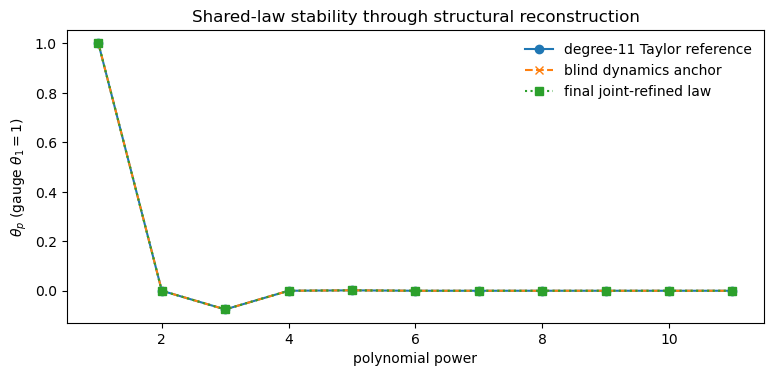

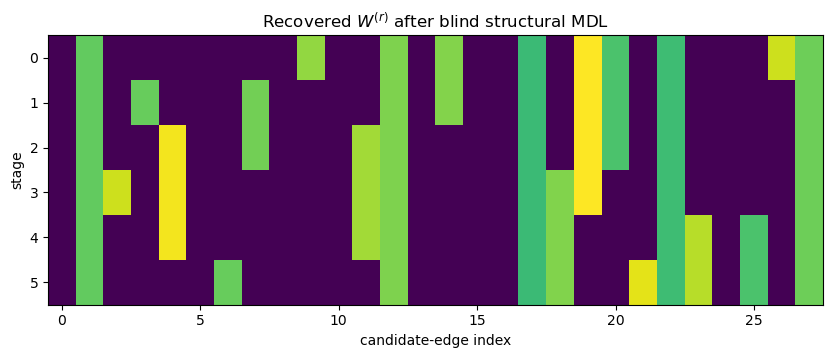

In [10]:

# ============================================================
# Cell 10 — Shared-law stability + amplitude recovery
# ============================================================
theta_anchor = THETA_ANCHOR
theta_final = np.asarray(JOINT.continuous_theta, dtype=float)

theta_anchor_rel = (
    np.linalg.norm(theta_anchor - THETA_TAYLOR_GAUGE)
    / np.linalg.norm(THETA_TAYLOR_GAUGE)
)

theta_reference_selected = THETA_TAYLOR_GAUGE.copy()
for a in range(L):
    if a not in JOINT.active_atoms:
        theta_reference_selected[a] = 0.0

theta_final_rel = (
    np.linalg.norm(theta_final - theta_reference_selected)
    / np.linalg.norm(theta_reference_selected)
)

W_TRUE_GAUGE = np.zeros((N_STAGES, M), dtype=float)
for r, snapshot in enumerate(SNAPSHOTS):
    for edge in snapshot:
        W_TRUE_GAUGE[r, EDGE_INDEX_1B[edge]] = DIFF_SCALE * EDGE_WEIGHT[edge]

dW_TRUE_GAUGE = np.diff(W_TRUE_GAUGE, axis=0)
active_W = W_TRUE_GAUGE != 0.0
active_dW = dW_TRUE_GAUGE != 0.0

W_cont_rel = (
    np.linalg.norm(
        (JOINT.continuous_W_stages - W_TRUE_GAUGE)[active_W]
    )
    / np.linalg.norm(W_TRUE_GAUGE[active_W])
)
dW_cont_rel = (
    np.linalg.norm(
        (np.diff(JOINT.continuous_W_stages, axis=0) - dW_TRUE_GAUGE)[active_dW]
    )
    / np.linalg.norm(dW_TRUE_GAUGE[active_dW])
)
W_finite_rel = (
    np.linalg.norm(
        (JOINT.W_stages - W_TRUE_GAUGE)[active_W]
    )
    / np.linalg.norm(W_TRUE_GAUGE[active_W])
)
inactive_W_max = float(np.max(np.abs(JOINT.continuous_W_stages[~active_W])))

print("=" * 90)
print("JOINT DYNAMICS / STRUCTURE AUDIT")
print("=" * 90)
print("theta anchor vs Taylor rel.err :", f"{theta_anchor_rel:.12e}")
print("theta final vs selected ref    :", f"{theta_final_rel:.12e}")
print("anchor -> final theta drift    :", f"{JOINT.metadata['theta_anchor_to_final_relative_change']:.12e}")
print("continuous W rel.err           :", f"{W_cont_rel:.12e}")
print("continuous Delta-W rel.err     :", f"{dW_cont_rel:.12e}")
print("finite-precision W rel.err     :", f"{W_finite_rel:.12e}")
print("max inactive continuous |W|    :", f"{inactive_W_max:.12e}")
print("active polynomial powers       :", tuple(a + 1 for a in JOINT.active_atoms))

print("\nStructural-step Theta motion:")
for h in JOINT.search_result.structural_history:
    print(
        f"  {h.move.label():18s} | "
        f"screen rho={h.screened_relative_residual:.3e} | "
        f"relative theta update={h.theta_relative_change:.3e}"
    )

assert theta_anchor_rel < 1e-6
assert theta_final_rel < 1e-6
assert W_cont_rel < 1e-8
assert dW_cont_rel < 1e-8
assert inactive_W_max < 1e-8
assert all((a + 1) % 2 == 1 for a in JOINT.active_atoms)

fig, ax = plt.subplots(figsize=(9, 3.8))
powers = np.arange(1, L + 1)
ax.plot(powers, THETA_TAYLOR_GAUGE, "o-", label="degree-11 Taylor reference")
ax.plot(powers, theta_anchor, "x--", label="blind dynamics anchor")
ax.plot(powers, theta_final, "s:", label="final joint-refined law")
ax.set_xlabel("polynomial power")
ax.set_ylabel(r"$\theta_p$ (gauge $\theta_1=1$)")
ax.set_title("Shared-law stability through structural reconstruction")
ax.legend(frameon=False)
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.imshow(JOINT.continuous_W_stages, aspect="auto")
ax.set_xlabel("candidate-edge index")
ax.set_ylabel("stage")
ax.set_title(r"Recovered $W^{(r)}$ after blind structural MDL")
plt.show()


COMPRESSION PATH
00 | initial              |   6988.067 bits
01 | drop_batch(53)       |   5013.165 bits
02 | drop_batch(85)       |   1701.320 bits
03 | drop_atom(1)         |   1665.642 bits
04 | drop_atom(3)         |   1628.812 bits
05 | drop_atom(5)         |   1591.227 bits
06 | drop_atom(7)         |   1553.034 bits
07 | drop_atom(9)         |   1514.298 bits
08 | drop_atom(10)        |   1473.160 bits


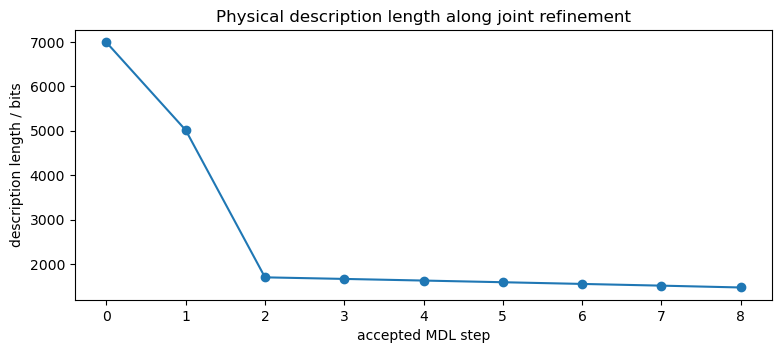

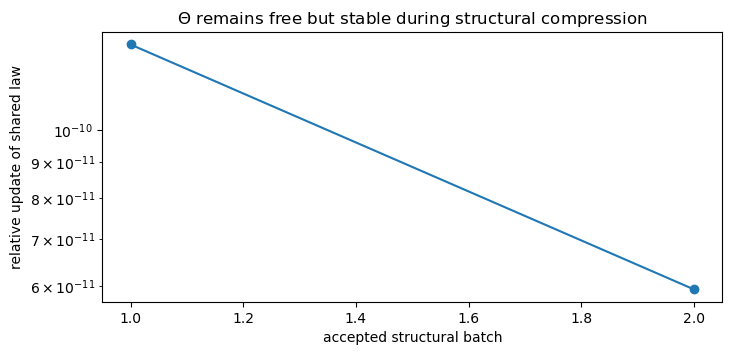

In [11]:

# ============================================================
# Cell 11 — MDL and Theta-stability path
# ============================================================
mdl_bits = [JOINT.search_result.initial_state.mdl_upper.total_bits]
labels = ["initial"]

for h in JOINT.search_result.history:
    mdl_bits.append(h.new_mdl_upper / np.log(2))
    labels.append(h.move.label())

print("=" * 90)
print("COMPRESSION PATH")
print("=" * 90)
for i, (label, bits) in enumerate(zip(labels, mdl_bits)):
    print(f"{i:02d} | {label:20s} | {bits:10.3f} bits")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(np.arange(len(mdl_bits)), mdl_bits, "o-")
ax.set_xlabel("accepted MDL step")
ax.set_ylabel("description length / bits")
ax.set_title("Physical description length along joint refinement")
plt.show()

if JOINT.search_result.structural_history:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    vals = [h.theta_relative_change for h in JOINT.search_result.structural_history]
    ax.semilogy(np.arange(1, len(vals) + 1), vals, "o-")
    ax.set_xlabel("accepted structural batch")
    ax.set_ylabel("relative update of shared law")
    ax.set_title(r"$\Theta$ remains free but stable during structural compression")
    plt.show()


In [12]:

# ============================================================
# Cell 12 — Final benchmark summary
# ============================================================
print("=" * 90)
print("N=8 KURAMOTO / JOINT-REFINEMENT TIDES SUMMARY")
print("=" * 90)
print("Step 1 exact transitions            :", np.array_equal(BASE.transition_indices, true_transition_indices))
print("midpoint observations               :", BASE.preprocessing.n_observations)
print("uncertainty floor                   :", f"{BASE.uncertainty_floor:.6e}")
print("Step 2 B shape                      :", FAMILY.reference_B_stages.shape)
print("Step 2 rank / nullity               :", FAMILY.rank, "/", FAMILY.nullity)
print("alternative Step-2 member feasible  :", FAMILY.is_feasible(B_ALT))
print("shared-law anchor/Taylor rel.err    :", f"{theta_anchor_rel:.6e}")
print("structural groups                   :", f"{len(JOINT.search_result.initial_state.active_groups)} -> {len(JOINT.search_result.best_state.active_groups)}")
print("baseline support exact              :", baseline_exact)
print("all Delta-W supports exact          :", all(changes_exact))
print("continuous W rel.err                :", f"{W_cont_rel:.6e}")
print("continuous Delta-W rel.err          :", f"{dW_cont_rel:.6e}")
print("final active polynomial powers      :", tuple(a + 1 for a in JOINT.active_atoms))
print("final joint residual                :", f"{JOINT.relative_residual:.6e}")
print("MDL bits                            :", f"{JOINT.search_result.initial_state.mdl_upper.total_bits:.3f} -> {JOINT.mdl_score.total_bits:.3f}")
print("anchor -> final Theta relative drift:", f"{JOINT.metadata['theta_anchor_to_final_relative_change']:.6e}")
print("=" * 90)

assert baseline_exact and all(changes_exact)
assert JOINT.feasible
assert W_cont_rel < 1e-8
assert dW_cont_rel < 1e-8
assert theta_anchor_rel < 1e-6

print("JOINT-REFINEMENT N=8 BENCHMARK: PASS")


N=8 KURAMOTO / JOINT-REFINEMENT TIDES SUMMARY
Step 1 exact transitions            : True
midpoint observations               : 708
uncertainty floor                   : 1.038246e-11
Step 2 B shape                      : (6, 28, 11)
Step 2 rank / nullity               : 498 / 1350
alternative Step-2 member feasible  : True
shared-law anchor/Taylor rel.err    : 1.471048e-10
structural groups                   : 168 -> 30
baseline support exact              : True
all Delta-W supports exact          : True
continuous W rel.err                : 3.118726e-12
continuous Delta-W rel.err          : 2.988386e-12
final active polynomial powers      : (1, 3, 5, 7, 9)
final joint residual                : 9.167237e-12
MDL bits                            : 6988.067 -> 1473.160
anchor -> final Theta relative drift: 1.671619e-09
JOINT-REFINEMENT N=8 BENCHMARK: PASS
